# Evaluación del modelo clasificador de riesgo IA

En este notebook evaluamos el modelo entrenado sobre el conjunto de test.

Métricas:
1. Classification report (precision, recall, f1 por clase)
2. F1-score macro
3. Matriz de confusión
4. Curva ROC multiclase (One-vs-Rest)
5. Análisis de errores
6. Registro de métricas en MLflow

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

# Localizar src/classifier/ de forma robusta y ajustar cwd al directorio
# de este notebook para que rutas relativas (datasets/, data/, model/) funcionen
# independientemente de desde donde se lance Jupyter/VS Code.
_cwd = os.getcwd()
_candidates = [
    os.path.join(_cwd, "src", "classifier"),
    os.path.abspath(".."),
    os.path.abspath("."),
]
for _p in _candidates:
    if os.path.isfile(os.path.join(_p, "functions.py")):
        if _p not in sys.path:
            sys.path.insert(0, _p)
        # Cambiar cwd al directorio de este notebook
        os.chdir(os.path.join(_p, "classifier_dataset_fusionado"))
        break

import functions  # noqa: E402
functions.MLFLOW_EXPERIMENT = "clasificador_riesgo_dataset_fusionado"
functions._DATASET_TAGS = {"dataset_type": "fusionado", "dataset_source": "eu_ai_act_flagged"}

## 1. Carga del modelo y datos de test

In [3]:
from pathlib import Path
import os
import pandas as pd
import joblib
from scipy.sparse import csr_matrix, hstack

# Cargar modelo y artefactos del pipeline
modelo = joblib.load("model/modelo_baseline.joblib")
tfidf  = joblib.load("model/tfidf_vectorizer.joblib")

ohe_path = Path("model/ohe_encoder.joblib")
if not ohe_path.exists():
    raise FileNotFoundError(
        "Artefacto requerido no encontrado: model/ohe_encoder.joblib. "
        "Ejecuta el notebook de entrenamiento antes de evaluar."
    )
ohe = joblib.load(ohe_path)

print("Artefactos cargados correctamente.")

test_path = Path("data/processed/test.csv")
if not test_path.exists():
    raise FileNotFoundError(
        f"Datos de test no encontrados: {test_path}. "
        "Ejecuta el preprocesado antes de evaluar."
    )

test_df = pd.read_csv(test_path)
X_test_text = test_df["text_final"]
y_test      = test_df["etiqueta"]

# Construir la misma matriz de features que usó el entrenamiento
X_test_tfidf = tfidf.transform(X_test_text)

CAT_COLS = ["category", "context"]
NUM_COLS = ["longitud", "num_articles"]
cat_test = ohe.transform(test_df[CAT_COLS])
num_test = csr_matrix(test_df[NUM_COLS].values.astype(float))
X_test_final = hstack([X_test_tfidf, cat_test, num_test])
print(f"Pipeline: TF-IDF ({X_test_tfidf.shape[1]}) + OHE ({cat_test.shape[1]}) + numéricas ({len(NUM_COLS)}) = {X_test_final.shape[1]} features")

print(f"\nTest: {len(X_test_text)} muestras")
print(f"Clases: {sorted(y_test.unique())}")

Artefactos cargados correctamente.
Pipeline: TF-IDF (5000) + OHE (22) + numéricas (2) = 5024 features

Test: 90 muestras
Clases: ['alto_riesgo', 'inaceptable', 'riesgo_limitado', 'riesgo_minimo']


c:\Users\rammu\anaconda3\envs\venv_proyecto\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\rammu\anaconda3\envs\venv_proyecto\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\rammu\anaconda3\envs\venv_proyecto\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from ver

## 2. Classification report y F1-score macro

In [4]:
from functions import evaluar_modelo

y_pred, report_dict = evaluar_modelo(modelo, X_test_final, y_test)

=== Resultados en TEST ===

                 precision    recall  f1-score   support

    alto_riesgo       0.95      0.90      0.93        21
    inaceptable       0.76      0.71      0.73        31
riesgo_limitado       0.85      0.85      0.85        13
  riesgo_minimo       0.68      0.76      0.72        25

       accuracy                           0.79        90
      macro avg       0.81      0.81      0.81        90
   weighted avg       0.79      0.79      0.79        90

F1-score macro (test): 0.8058



## 3. Matriz de confusión

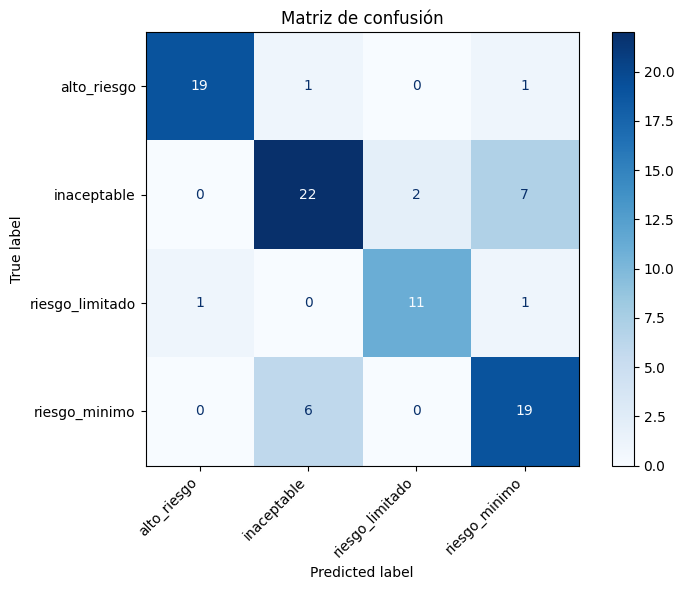

In [5]:
from functions import mostrar_matriz_confusion

clases = sorted(y_test.unique())
fig_cm = mostrar_matriz_confusion(y_test, y_pred, labels=clases)

## 4. Curva ROC multiclase

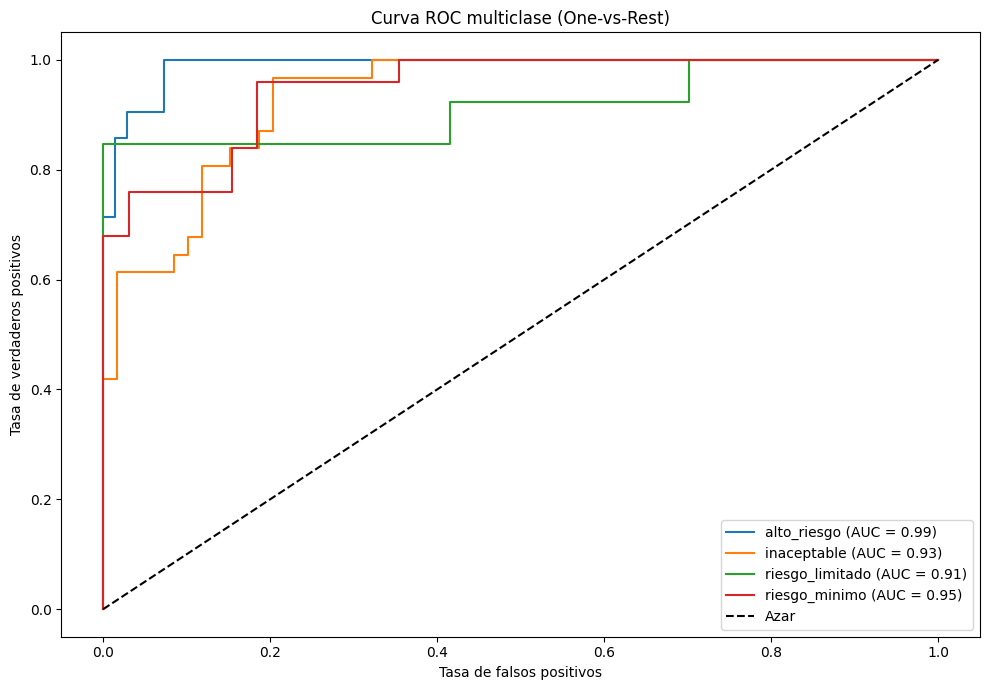


ROC AUC macro: 0.9468
  alto_riesgo: 0.9896
  inaceptable: 0.9344
  riesgo_limitado: 0.9141
  riesgo_minimo: 0.9489


In [6]:
from functions import plot_curva_roc_multiclase

fig_roc, roc_auc_dict = plot_curva_roc_multiclase(modelo, X_test_final, y_test)

## 5. Análisis de errores

In [7]:
from functions import analisis_errores

df_errores = analisis_errores(modelo, X_test_final, y_test, X_test_text=X_test_text)

Total de errores: 19 de 90 (21.1%)

Confusiones más frecuentes:
etiqueta_real    etiqueta_predicha
inaceptable      riesgo_minimo        7
riesgo_minimo    inaceptable          6
inaceptable      riesgo_limitado      2
alto_riesgo      riesgo_minimo        1
                 inaceptable          1
riesgo_limitado  alto_riesgo          1
                 riesgo_minimo        1
dtype: int64

Ejemplos mal clasificados:
  Real: riesgo_minimo | Predicho: inaceptable
  Texto: sistema inteligencia artificial proporciona información tráfico tiempo real conductores través aplicación móvil utilizan...

  Real: alto_riesgo | Predicho: riesgo_minimo
  Texto: empresa servicios legales utiliza sistema inteligencia artificial automatizar revisión contratos sistema basa datos pers...

  Real: inaceptable | Predicho: riesgo_minimo
  Texto: plataforma comercio electrónico utiliza sistema recomendación impulsado inteligencia artificial manipula usuarios realic...

  Real: riesgo_minimo | Predicho: inacep

## 6. Registro de métricas en MLflow

In [8]:
# ── MLflow (solo falla esta celda si el servidor no está disponible) ──
import numpy as np
import mlflow
from functions import configure_mlflow, MLFLOW_EXPERIMENT

# Guardar gráficos localmente (no depende del servidor)
fig_cm.savefig("model/matriz_confusion.png", dpi=150, bbox_inches="tight")
fig_roc.savefig("model/curva_roc.png", dpi=150, bbox_inches="tight")

try:
    configure_mlflow()
    mlflow.set_experiment(MLFLOW_EXPERIMENT)

    with mlflow.start_run(run_name="evaluacion_test"):
        mlflow.log_metric("test_f1_macro",        report_dict["macro avg"]["f1-score"])
        mlflow.log_metric("test_accuracy",         report_dict["accuracy"])
        mlflow.log_metric("test_precision_macro",  report_dict["macro avg"]["precision"])
        mlflow.log_metric("test_recall_macro",     report_dict["macro avg"]["recall"])

        for clase, auc_val in roc_auc_dict.items():
            mlflow.log_metric(f"test_roc_auc_{clase}", auc_val)
        mlflow.log_metric("test_roc_auc_macro", np.mean(list(roc_auc_dict.values())))

        mlflow.log_artifact("model/matriz_confusion.png")
        mlflow.log_artifact("model/curva_roc.png")

        print("✓ Métricas de test registradas en MLflow")
        print(f"  F1-score macro: {report_dict['macro avg']['f1-score']:.4f}")
        print(f"  Run ID: {mlflow.active_run().info.run_id}")
except Exception as e:
    print(f"⚠ MLflow no disponible: {e}")

Password obtenida desde variable de entorno local.
MLflow configurado correctamente → https://18.201.64.41/
⚠ MLflow no disponible: API request to https://18.201.64.41/api/2.0/mlflow/experiments/get-by-name failed with timeout exception HTTPSConnectionPool(host='18.201.64.41', port=443): Max retries exceeded with url: /api/2.0/mlflow/experiments/get-by-name?experiment_name=clasificador_riesgo_dataset_fusionado (Caused by ConnectTimeoutError(<HTTPSConnection(host='18.201.64.41', port=443) at 0x23bf2e27e60>, 'Connection to 18.201.64.41 timed out. (connect timeout=120)')). To increase the timeout, set the environment variable MLFLOW_HTTP_REQUEST_TIMEOUT (default: 120, type: int) to a larger value.


Instala las dependencias desde `requirements.txt` antes de ejecutar este notebook:
```bash
pip install -r requirements.txt
```

## 7. Conclusiones

Documentar aquí las conclusiones tras observar las métricas:
- ¿Qué clases se confunden más entre sí?
- ¿El modelo generaliza bien o muestra signos de overfitting?
- ¿Qué mejoras se podrían probar en iteraciones futuras?